In [37]:
import pandas as pd
import duckdb, glob, os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PARQUET_PATH = "/Users/lecasarino/ecommerce_4months_full.parquet"

con = duckdb.connect()
con.execute("PRAGMA threads=4;")
con.execute("PRAGMA enable_object_cache=true;")
con.execute(f"""
CREATE OR REPLACE VIEW events AS
SELECT * FROM read_parquet('{PARQUET_PATH}');
""")

# Базовый summary

In [3]:
summary = con.execute("""
SELECT
  COUNT(*) AS rows,
  COUNT(DISTINCT user_id) AS users,
  COUNT(DISTINCT product_id) AS products,
  COUNT(DISTINCT user_session) AS sessions,
  MIN(event_time) AS min_time,
  MAX(event_time) AS max_time
FROM events
""").df()

summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,users,products,sessions,min_time,max_time
0,246330463,10723863,306293,56293798,2019-11-01 03:00:00+03:00,2020-03-01 02:59:59+03:00


# Распределение событий + funnel

In [4]:
event_dist = con.execute("""
SELECT event_type, COUNT(*) AS cnt
FROM events
GROUP BY event_type
ORDER BY cnt DESC
""").df()

event_dist["share"] = event_dist["cnt"] / event_dist["cnt"].sum()
event_dist

,event_type,cnt,share
0,view,230265631,0.934783
1,cart,11950550,0.048514
2,purchase,4114282,0.016702


In [5]:
funnel = con.execute("""
SELECT
  SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS views,
  SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS carts,
  SUM(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS purchases
FROM events
""").df()

views = int(funnel.loc[0, "views"])
carts = int(funnel.loc[0, "carts"])
purchases = int(funnel.loc[0, "purchases"])

funnel, {
    "view_to_cart": carts / views,
    "cart_to_purchase": purchases / carts,
    "view_to_purchase": purchases / views
}

(         views       carts  purchases
 0  230265631.0  11950550.0  4114282.0,
 {'view_to_cart': 0.051898974015796566,
  'cart_to_purchase': 0.34427553543560757,
  'view_to_purchase': 0.017867547067847045})

# Доля покупателей среди пользователей

In [6]:
buyers = con.execute("""
SELECT
  COUNT(DISTINCT user_id) AS buyers
FROM events
WHERE event_type='purchase'
""").df()

total_users = int(summary.loc[0, "users"])
buyers_cnt = int(buyers.loc[0, "buyers"])
buyers_share = buyers_cnt / total_users

buyers, {"buyers_share": buyers_share}

(    buyers
 0  1289317,
 {'buyers_share': 0.12022878322858097})

# Повторные покупки

In [7]:
# Покупки на пользователя (перцентили + доли)
purchase_user_stats = con.execute("""
WITH pu AS (
  SELECT user_id, COUNT(*) AS purchases_cnt
  FROM events
  WHERE event_type='purchase'
  GROUP BY user_id
)
SELECT
  COUNT(*) AS buyers,
  AVG(purchases_cnt) AS mean_purchases_per_buyer,
  quantile_cont(purchases_cnt, 0.50) AS p50,
  quantile_cont(purchases_cnt, 0.90) AS p90,
  quantile_cont(purchases_cnt, 0.95) AS p95,
  quantile_cont(purchases_cnt, 0.99) AS p99,
  MAX(purchases_cnt) AS max_val
FROM pu
""").df()

purchase_user_stats

,buyers,mean_purchases_per_buyer,p50,p90,p95,p99,max_val
0,1289317,3.191055,2.0,6.0,10.0,27.0,1961


In [8]:
# Доля повторных покупателей (>=2 покупки)
repeat_buyers = con.execute("""
WITH pu AS (
  SELECT user_id, COUNT(*) AS purchases_cnt
  FROM events
  WHERE event_type='purchase'
  GROUP BY user_id
)
SELECT
  SUM(CASE WHEN purchases_cnt >= 2 THEN 1 ELSE 0 END) AS repeat_buyers,
  COUNT(*) AS buyers,
  SUM(CASE WHEN purchases_cnt >= 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS repeat_share
FROM pu
""").df()

repeat_buyers

,repeat_buyers,buyers,repeat_share
0,661602.0,1289317,0.513141


# Временная динамика (месяц / день недели / час)

In [9]:
monthly = con.execute("""
SELECT
  date_trunc('month', event_time) AS month,
  event_type,
  COUNT(*) AS cnt
FROM events
GROUP BY 1,2
ORDER BY 1,2
""").df()

monthly

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,event_type,cnt
0,2019-11-01 00:00:00+03:00,cart,3027229
1,2019-11-01 00:00:00+03:00,purchase,916190
2,2019-11-01 00:00:00+03:00,view,63511182
3,2019-12-01 00:00:00+03:00,cart,3394441
4,2019-12-01 00:00:00+03:00,purchase,1162797
5,2019-12-01 00:00:00+03:00,view,62973795
6,2020-01-01 00:00:00+03:00,cart,2639127
7,2020-01-01 00:00:00+03:00,purchase,834159
8,2020-01-01 00:00:00+03:00,view,52494488
9,2020-02-01 00:00:00+03:00,cart,2888691


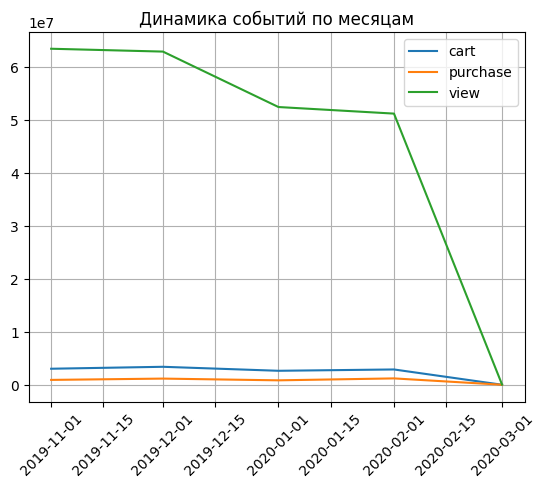

In [10]:
pivot = monthly.pivot(index="month", columns="event_type", values="cnt").fillna(0)

plt.figure()
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=str(col))
plt.title("Динамика событий по месяцам")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

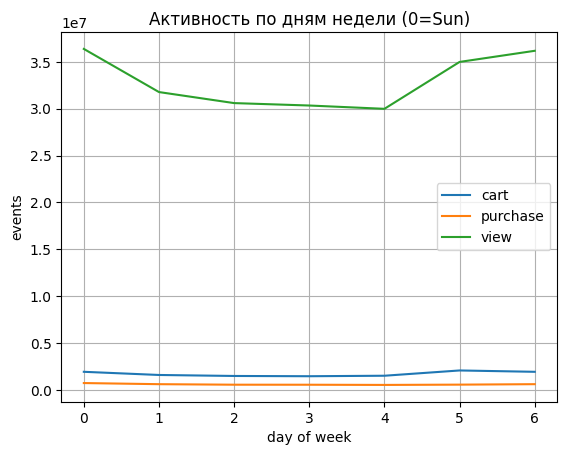

In [11]:
dow = con.execute("""
SELECT
  EXTRACT(dow FROM event_time) AS dow,  -- 0=Sunday
  event_type,
  COUNT(*) AS cnt
FROM events
GROUP BY 1,2
ORDER BY 1,2
""").df()

pivot_dow = dow.pivot(index="dow", columns="event_type", values="cnt").fillna(0)

plt.figure()
for col in pivot_dow.columns:
    plt.plot(pivot_dow.index, pivot_dow[col], label=str(col))
plt.title("Активность по дням недели (0=Sun)")
plt.xlabel("day of week")
plt.ylabel("events")
plt.legend()
plt.grid()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

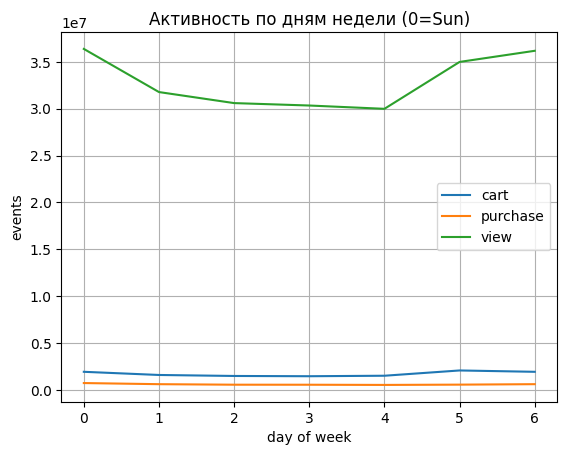

In [12]:
dow = con.execute("""
SELECT
  EXTRACT(dow FROM event_time) AS dow,  -- 0=Sunday
  event_type,
  COUNT(*) AS cnt
FROM events
GROUP BY 1,2
ORDER BY 1,2
""").df()

pivot_dow = dow.pivot(index="dow", columns="event_type", values="cnt").fillna(0)

plt.figure()
for col in pivot_dow.columns:
    plt.plot(pivot_dow.index, pivot_dow[col], label=str(col))
plt.title("Активность по дням недели (0=Sun)")
plt.xlabel("day of week")
plt.ylabel("events")
plt.legend()
plt.grid()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

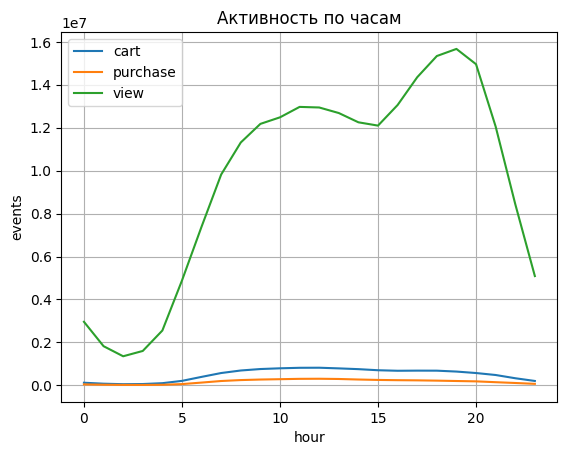

In [13]:
hourly = con.execute("""
SELECT
  EXTRACT(hour FROM event_time) AS hour,
  event_type,
  COUNT(*) AS cnt
FROM events
GROUP BY 1,2
ORDER BY 1,2
""").df()

pivot_h = hourly.pivot(index="hour", columns="event_type", values="cnt").fillna(0)

plt.figure()
for col in pivot_h.columns:
    plt.plot(pivot_h.index, pivot_h[col], label=str(col))
plt.title("Активность по часам")
plt.xlabel("hour")
plt.ylabel("events")
plt.legend()
plt.grid()
plt.show()

# Цены: распределение + квантили

In [14]:
# Резюме цены (по sample)
price_sample = con.execute("""
SELECT price
FROM events
WHERE price IS NOT NULL AND price > 0
  AND random() < 0.005   -- ~0.5% sample
""").df()

price_sample.shape, price_sample.describe()

((1228280, 1),
               price
 count  1.228280e+06
 mean   2.864771e+02
 std    3.553525e+02
 min    7.700000e-01
 25%    6.433000e+01
 50%    1.634500e+02
 75%    3.474700e+02
 max    2.574070e+03)

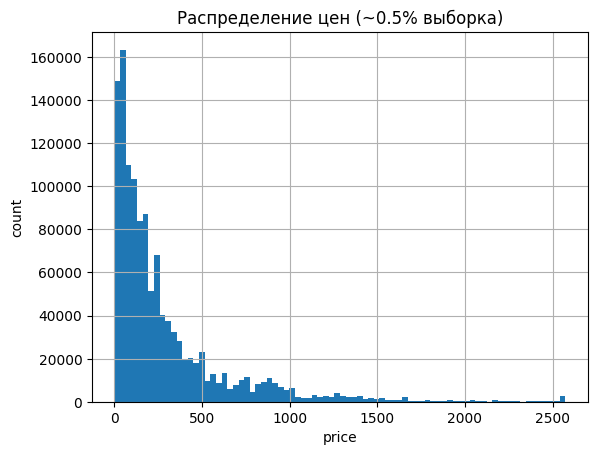

In [15]:
plt.figure()
plt.hist(price_sample["price"], bins=80)
plt.title("Распределение цен (~0.5% выборка)")
plt.xlabel("price")
plt.ylabel("count")
plt.grid()
plt.show()

In [16]:
# Квантили цены на полных данных
price_quantiles = con.execute("""
SELECT
  quantile_cont(price, 0.25) AS q25,
  quantile_cont(price, 0.50) AS q50,
  quantile_cont(price, 0.75) AS q75,
  quantile_cont(price, 0.90) AS q90,
  quantile_cont(price, 0.95) AS q95,
  quantile_cont(price, 0.99) AS q99
FROM events
WHERE price IS NOT NULL AND price > 0
""").df()

price_quantiles

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,q25,q50,q75,q90,q95,q99
0,64.349998,164.080002,347.76001,745.190002,979.539978,1688.329956


# Конверсия по цене (квантили)

In [17]:
# Создаём таблицу взаимодействий
con.execute("DROP TABLE IF EXISTS interactions;")

con.execute("""
CREATE TABLE interactions AS
SELECT
  user_id,
  product_id,
  MAX(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS viewed,
  MAX(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS carted,
  MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS purchased,
  MAX(price) AS price_max
FROM events
GROUP BY user_id, product_id;
""")

# Быстрый контроль размеров
inter_summary = con.execute("""
SELECT
  COUNT(*) AS rows,
  SUM(viewed) AS viewed_pairs,
  SUM(carted) AS carted_pairs,
  SUM(purchased) AS purchased_pairs
FROM interactions
""").df()

inter_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,viewed_pairs,carted_pairs,purchased_pairs
0,122394151,122253543.0,5860785.0,2773883.0


In [18]:
# Конверсия view→purchase по квантилям цены
conv_price = con.execute("""
WITH base AS (
  SELECT
    *,
    ntile(10) OVER (ORDER BY price_max) AS price_decile
  FROM interactions
  WHERE viewed=1 AND price_max IS NOT NULL AND price_max > 0
)
SELECT
  price_decile,
  COUNT(*) AS viewed_pairs,
  SUM(CASE WHEN carted=1 THEN 1 ELSE 0 END) AS cart_pairs,
  SUM(CASE WHEN purchased=1 THEN 1 ELSE 0 END) AS purchase_pairs,
  SUM(CASE WHEN carted=1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS view_to_cart,
  SUM(CASE WHEN purchased=1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS view_to_purchase
FROM base
GROUP BY 1
ORDER BY 1;
""").df()

conv_price

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,price_decile,viewed_pairs,cart_pairs,purchase_pairs,view_to_cart,view_to_purchase
0,1,12193547,536997.0,185987.0,0.044039,0.015253
1,2,12193547,582450.0,239892.0,0.047767,0.019674
2,3,12193546,498771.0,226356.0,0.040905,0.018564
3,4,12193546,470464.0,222417.0,0.038583,0.018241
4,5,12193546,640090.0,334930.0,0.052494,0.027468
5,6,12193546,712012.0,372401.0,0.058393,0.030541
6,7,12193546,664077.0,336058.0,0.054461,0.027560
7,8,12193546,540607.0,268857.0,0.044336,0.022049
8,9,12193546,512416.0,254243.0,0.042024,0.020851
9,10,12193546,589696.0,299204.0,0.048361,0.024538


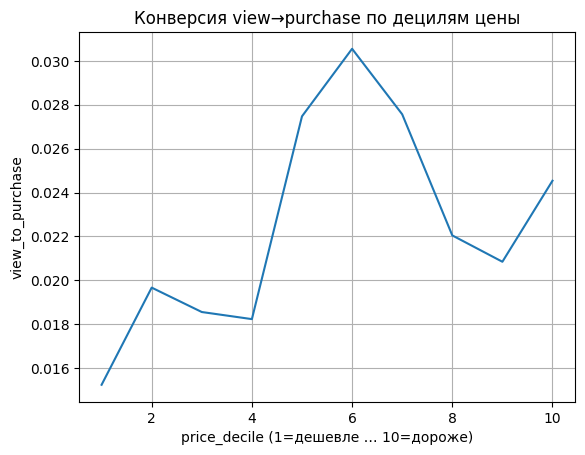

In [19]:
plt.figure()
plt.plot(conv_price["price_decile"], conv_price["view_to_purchase"])
plt.title("Конверсия view→purchase по децилям цены")
plt.xlabel("price_decile (1=дешевле … 10=дороже)")
plt.ylabel("view_to_purchase")
plt.grid()
plt.show()

In [20]:
# Конверсия cart→purchase по квантилям цены
conv_price_cart = con.execute("""
WITH base AS (
  SELECT
    *,
    ntile(10) OVER (ORDER BY price_max) AS price_decile
  FROM interactions
  WHERE carted=1 AND price_max IS NOT NULL AND price_max > 0
)
SELECT
  price_decile,
  COUNT(*) AS cart_pairs,
  SUM(CASE WHEN purchased=1 THEN 1 ELSE 0 END) AS purchase_pairs,
  SUM(CASE WHEN purchased=1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS cart_to_purchase
FROM base
GROUP BY 1
ORDER BY 1;
""").df()

conv_price_cart

,price_decile,cart_pairs,purchase_pairs,cart_to_purchase
0,1,585682,192158.0,0.328093
1,2,585682,223660.0,0.381880
2,3,585682,245587.0,0.419318
3,4,585682,264654.0,0.451873
4,5,585682,295258.0,0.504127
5,6,585682,294018.0,0.502010
6,7,585681,284330.0,0.485469
7,8,585681,271394.0,0.463382
8,9,585681,274779.0,0.469162
9,10,585681,281650.0,0.480893


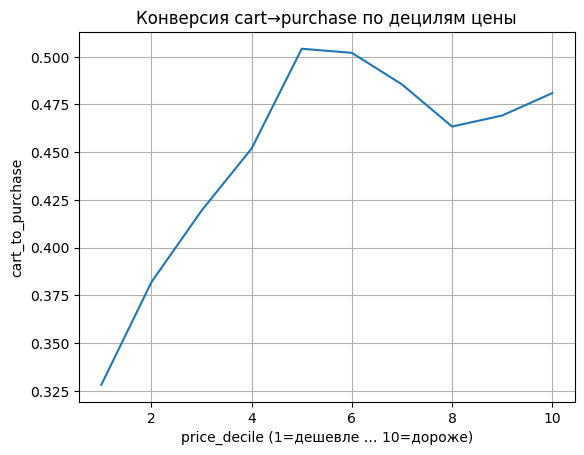

In [21]:
plt.figure()
plt.plot(conv_price_cart["price_decile"], conv_price_cart["cart_to_purchase"])
plt.title("Конверсия cart→purchase по децилям цены")
plt.xlabel("price_decile (1=дешевле … 10=дороже)")
plt.ylabel("cart_to_purchase")
plt.grid()
plt.show()

# Конверсия по активности пользователя

In [22]:
# Соберём признаки активности (события на пользователя)
con.execute("DROP TABLE IF EXISTS user_activity;")

con.execute("""
CREATE TABLE user_activity AS
SELECT
  user_id,
  COUNT(*) AS events_cnt,
  SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS views_cnt,
  SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS carts_cnt,
  SUM(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS purchases_cnt
FROM events
GROUP BY user_id;
""")

ua_pct = con.execute("""
SELECT
  quantile_cont(events_cnt, 0.50) AS p50,
  quantile_cont(events_cnt, 0.90) AS p90,
  quantile_cont(events_cnt, 0.95) AS p95,
  quantile_cont(events_cnt, 0.99) AS p99,
  MAX(events_cnt) AS max_val
FROM user_activity
""").df()

ua_pct

,p50,p90,p95,p99,max_val
0,4.0,55.0,101.0,281.0,95597


In [23]:
# Сегменты активности и вероятность покупки
# Сделаем 5 сегментов по квантилям (quintiles) и посмотрим долю покупателей.
activity_conv = con.execute("""
WITH seg AS (
  SELECT
    user_id,
    events_cnt,
    purchases_cnt,
    ntile(5) OVER (ORDER BY events_cnt) AS activity_quintile
  FROM user_activity
)
SELECT
  activity_quintile,
  COUNT(*) AS users,
  SUM(CASE WHEN purchases_cnt > 0 THEN 1 ELSE 0 END) AS buyers,
  SUM(CASE WHEN purchases_cnt > 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS buyer_share,
  AVG(purchases_cnt) AS avg_purchases
FROM seg
GROUP BY 1
ORDER BY 1;
""").df()

activity_conv

,activity_quintile,users,buyers,buyer_share,avg_purchases
0,1,2144773,3036.0,0.001416,0.001416
1,2,2144773,11634.0,0.005424,0.005826
2,3,2144773,115629.0,0.053912,0.060494
3,4,2144772,318911.0,0.148692,0.242238
4,5,2144772,840107.0,0.391700,1.608310


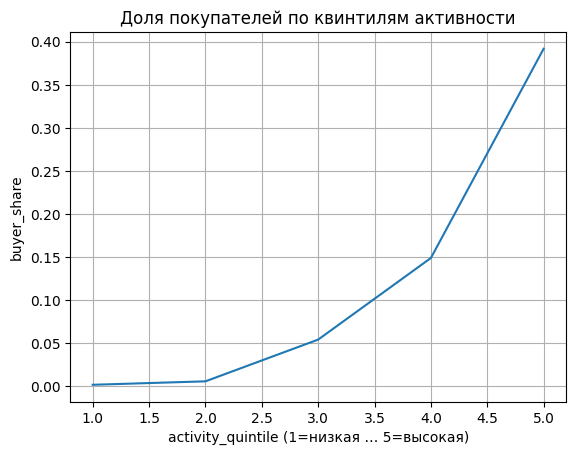

In [24]:
plt.figure()
plt.plot(activity_conv["activity_quintile"], activity_conv["buyer_share"])
plt.title("Доля покупателей по квинтилям активности")
plt.xlabel("activity_quintile (1=низкая … 5=высокая)")
plt.ylabel("buyer_share")
plt.grid()
plt.show()

# Анализ сессий: длина, длительность, конверсия

In [25]:
# Таблица сессий
con.execute("DROP TABLE IF EXISTS sessions;")

con.execute("""
CREATE TABLE sessions AS
SELECT
  user_session,
  ANY_VALUE(user_id) AS user_id,
  COUNT(*) AS events_cnt,
  COUNT(DISTINCT product_id) AS uniq_products,
  MIN(event_time) AS start_time,
  MAX(event_time) AS end_time,
  datediff('second', MIN(event_time), MAX(event_time)) AS duration_sec,
  MAX(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS has_cart,
  MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS has_purchase
FROM events
GROUP BY user_session;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [26]:
# Перцентили и базовые метрики по сессиям
sess_stats = con.execute("""
SELECT
  COUNT(*) AS sessions,
  AVG(events_cnt) AS avg_events,
  quantile_cont(events_cnt, 0.50) AS p50_events,
  quantile_cont(events_cnt, 0.90) AS p90_events,
  quantile_cont(duration_sec, 0.50) AS p50_duration,
  quantile_cont(duration_sec, 0.90) AS p90_duration,
  SUM(has_purchase) * 1.0 / COUNT(*) AS session_purchase_rate,
  SUM(has_cart) * 1.0 / COUNT(*) AS session_cart_rate
FROM sessions
""").df()

sess_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sessions,avg_events,p50_events,p90_events,p50_duration,p90_duration,session_purchase_rate,session_cart_rate
0,56293799,4.375801,2.0,10.0,32.0,705.0,0.056593,0.119541


In [27]:
# Конверсия в покупку по длине сессии (децили)
sess_len_conv = con.execute("""
WITH base AS (
  SELECT
    *,
    ntile(10) OVER (ORDER BY events_cnt) AS len_decile
  FROM sessions
)
SELECT
  len_decile,
  COUNT(*) AS sessions,
  AVG(duration_sec) AS avg_duration_sec,
  SUM(has_purchase) * 1.0 / COUNT(*) AS purchase_rate
FROM base
GROUP BY 1
ORDER BY 1;
""").df()

sess_len_conv

,len_decile,sessions,avg_duration_sec,purchase_rate
0,1,5629380,0.000000,0.001877
1,2,5629380,0.000000,0.001874
2,3,5629380,0.000000,0.001920
3,4,5629380,0.000000,0.001934
4,5,5629380,13380.397603,0.003725
5,6,5629380,25733.143308,0.025532
6,7,5629380,51285.702666,0.106426
7,8,5629380,81759.857726,0.145538
8,9,5629380,103196.228119,0.141163
9,10,5629379,146456.281028,0.135944


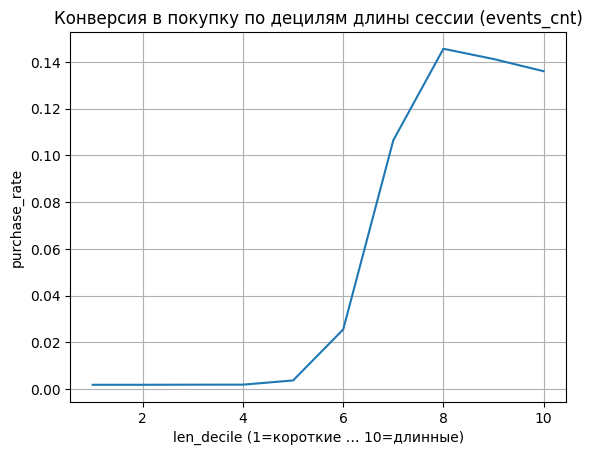

In [28]:
plt.figure()
plt.plot(sess_len_conv["len_decile"], sess_len_conv["purchase_rate"])
plt.title("Конверсия в покупку по децилям длины сессии (events_cnt)")
plt.xlabel("len_decile (1=короткие … 10=длинные)")
plt.ylabel("purchase_rate")
plt.grid()
plt.show()

# Топ категорий и брендов по конверсии

In [29]:
# Конверсия по category_code на уровне взаимодействий (viewed pairs)
# Чтобы не “перекосить” результат количеством событий, считаем на уровне user×product из interactions, а 
# категорию подтянем из исходных событий как наиболее частую.
# Создадим справочник product → category_code/brand (через ANY_VALUE).

con.execute("DROP TABLE IF EXISTS product_meta;")

con.execute("""
CREATE TABLE product_meta AS
SELECT
  product_id,
  ANY_VALUE(category_code) AS category_code,
  ANY_VALUE(brand) AS brand
FROM events
GROUP BY product_id;
""")

In [30]:
# Конверсия view→purchase по категориям (топ-30 по числу просмотров)
cat_conv = con.execute("""
WITH base AS (
  SELECT
    pm.category_code,
    i.viewed,
    i.carted,
    i.purchased
  FROM interactions i
  LEFT JOIN product_meta pm USING(product_id)
  WHERE i.viewed=1 AND pm.category_code IS NOT NULL
)
SELECT
  category_code,
  COUNT(*) AS viewed_pairs,
  SUM(carted) * 1.0 / COUNT(*) AS view_to_cart,
  SUM(purchased) * 1.0 / COUNT(*) AS view_to_purchase
FROM base
GROUP BY category_code
HAVING COUNT(*) >= 5000
ORDER BY view_to_purchase DESC
LIMIT 30;
""").df()

cat_conv

,category_code,viewed_pairs,view_to_cart,view_to_purchase
0,construction.tools.light,16894392,0.083168,0.046133
1,electronics.smartphone,9810036,0.068324,0.035519
2,appliances.iron,287250,0.068675,0.034604
3,sport.bicycle,2582521,0.061081,0.031029
4,appliances.kitchen.microwave,134246,0.058557,0.030303
5,appliances.environment.water_heater,147039,0.065173,0.029033
6,appliances.kitchen.washer,1751554,0.058541,0.028334
7,electronics.audio.headphone,3130112,0.056949,0.028128
8,appliances.environment.vacuum,2197647,0.051844,0.025797
9,electronics.video.tv,2053654,0.053010,0.025776


In [31]:
# Конверсия по брендам (топ-30)
brand_conv = con.execute("""
WITH base AS (
  SELECT
    pm.brand,
    i.viewed,
    i.carted,
    i.purchased
  FROM interactions i
  LEFT JOIN product_meta pm USING(product_id)
  WHERE i.viewed=1 AND pm.brand IS NOT NULL
)
SELECT
  brand,
  COUNT(*) AS viewed_pairs,
  SUM(carted) * 1.0 / COUNT(*) AS view_to_cart,
  SUM(purchased) * 1.0 / COUNT(*) AS view_to_purchase
FROM base
GROUP BY brand
HAVING COUNT(*) >= 5000
ORDER BY view_to_purchase DESC
LIMIT 30;
""").df()

brand_conv

,brand,viewed_pairs,view_to_cart,view_to_purchase
0,iqos,18535,0.129431,0.075964
1,electronicarts,21329,0.125838,0.067748
2,bars,67369,0.115231,0.054476
3,haday,5264,0.109422,0.052812
4,sunwide,6575,0.119240,0.051863
5,genesis,20229,0.107074,0.049434
6,joyroad,23654,0.123869,0.048491
7,glo,42283,0.109713,0.047490
8,apple,9544799,0.087451,0.047301
9,powertrac,48175,0.124733,0.046414


# Переходы между событиями

In [32]:
transitions = con.execute("""
WITH u AS (
  SELECT DISTINCT user_id
  FROM events
  WHERE random() < 0.01
),
ordered AS (
  SELECT
    e.user_id,
    e.event_time,
    e.event_type,
    LAG(e.event_type) OVER (PARTITION BY e.user_id ORDER BY e.event_time) AS prev_event
  FROM events e
  JOIN u USING(user_id)
)
SELECT prev_event, event_type, COUNT(*) AS cnt
FROM ordered
WHERE prev_event IS NOT NULL
GROUP BY 1,2
ORDER BY cnt DESC;
""").df()

transitions

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,prev_event,event_type,cnt
0,view,view,882086
1,view,cart,40214
2,cart,view,33737
3,view,purchase,13771
4,purchase,view,10930
5,cart,cart,6507
6,cart,purchase,3002
7,purchase,cart,2241
8,purchase,purchase,1453


# Экспорт ключевых таблиц

In [33]:
out_dir = "/Users/lecasarino/Downloads/eda_outputs"
import os
os.makedirs(out_dir, exist_ok=True)

summary.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
event_dist.to_csv(os.path.join(out_dir, "event_dist.csv"), index=False)
funnel.to_csv(os.path.join(out_dir, "funnel.csv"), index=False)
buyers.to_csv(os.path.join(out_dir, "buyers.csv"), index=False)
repeat_buyers.to_csv(os.path.join(out_dir, "repeat_buyers.csv"), index=False)
price_quantiles.to_csv(os.path.join(out_dir, "price_quantiles.csv"), index=False)
conv_price.to_csv(os.path.join(out_dir, "conversion_by_price_decile_view.csv"), index=False)
conv_price_cart.to_csv(os.path.join(out_dir, "conversion_by_price_decile_cart.csv"), index=False)
activity_conv.to_csv(os.path.join(out_dir, "conversion_by_activity.csv"), index=False)
sess_stats.to_csv(os.path.join(out_dir, "session_stats.csv"), index=False)
sess_len_conv.to_csv(os.path.join(out_dir, "session_len_conv.csv"), index=False)
cat_conv.to_csv(os.path.join(out_dir, "category_conversion_top30.csv"), index=False)
brand_conv.to_csv(os.path.join(out_dir, "brand_conversion_top30.csv"), index=False)
transitions.to_csv(os.path.join(out_dir, "transitions_sample.csv"), index=False)

print("Saved to:", out_dir)

Saved to: /Users/lecasarino/Downloads/eda_outputs


# Дополнительные блоки EDA
1. концентрация активности пользователей (top 1% / 5% / 10%)
2. скорость переходов (время view→cart и cart→purchase) на подвыборке
3. зависимость конверсии от «глубины просмотра» в рамках сессии (на подвыборке)
4. статистические проверки различий (χ² и z-тест для долей)

## 1. Концентрация активности пользователей

In [35]:
# Концентрация активности: доля событий у top пользователей (в % пользователей)
top_share = con.execute("""
WITH ua AS (
  SELECT user_id, COUNT(*) AS events_cnt
  FROM events
  GROUP BY user_id
),
ranked AS (
  SELECT
    events_cnt,
    ROW_NUMBER() OVER (ORDER BY events_cnt DESC) AS rn,
    COUNT(*) OVER () AS n_users,
    SUM(events_cnt) OVER () AS total_events
  FROM ua
)
SELECT
  SUM(CASE WHEN rn <= CAST(n_users*0.01 AS BIGINT) THEN events_cnt ELSE 0 END) * 1.0 / MAX(total_events) AS top1pct_share,
  SUM(CASE WHEN rn <= CAST(n_users*0.05 AS BIGINT) THEN events_cnt ELSE 0 END) * 1.0 / MAX(total_events) AS top5pct_share,
  SUM(CASE WHEN rn <= CAST(n_users*0.10 AS BIGINT) THEN events_cnt ELSE 0 END) * 1.0 / MAX(total_events) AS top10pct_share
FROM ranked
""").df()

top_share

,top1pct_share,top5pct_share,top10pct_share
0,0.221923,0.498667,0.65956


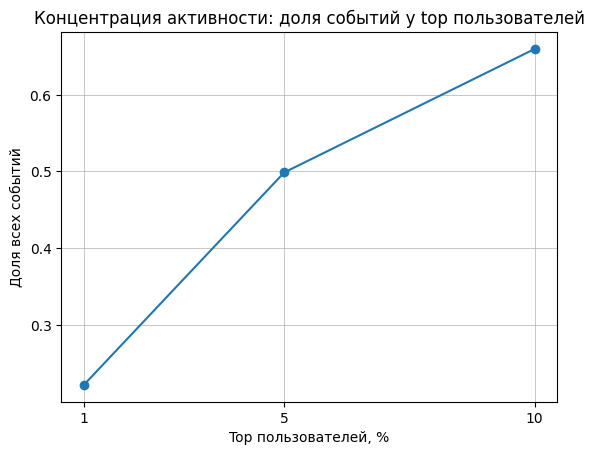

In [38]:
x = np.array([1, 5, 10])
y = np.array([
    float(top_share.loc[0, "top1pct_share"]),
    float(top_share.loc[0, "top5pct_share"]),
    float(top_share.loc[0, "top10pct_share"])
])

plt.figure()
plt.plot(x, y, marker="o")
plt.title("Концентрация активности: доля событий у top пользователей")
plt.xlabel("Top пользователей, %")
plt.ylabel("Доля всех событий")
plt.xticks(x)
plt.grid(True, linewidth=0.5)
plt.show()

## 2. Время до следующего шага (скорость переходов)

In [39]:
# Время переходов view→cart и cart→purchase на 1% пользователей (перцентили)
# При необходимости можно изменить долю пользователей: 0.01 → 0.02 (2%) или 0.005 (0.5%)
time_to_step = con.execute("""
WITH u AS (
  SELECT DISTINCT user_id
  FROM events
  WHERE random() < 0.01
),
ev AS (
  SELECT e.user_id, e.product_id, e.event_time, e.event_type
  FROM events e
  JOIN u USING(user_id)
),
views AS (
  SELECT user_id, product_id, event_time AS view_time
  FROM ev
  WHERE event_type='view'
),
carts AS (
  SELECT user_id, product_id, MIN(event_time) AS cart_time
  FROM ev
  WHERE event_type='cart'
  GROUP BY 1,2
),
purch AS (
  SELECT user_id, product_id, MIN(event_time) AS purchase_time
  FROM ev
  WHERE event_type='purchase'
  GROUP BY 1,2
),
v2c AS (
  SELECT
    v.user_id,
    v.product_id,
    MIN(datediff('second', v.view_time, c.cart_time)) AS sec_view_to_cart
  FROM views v
  JOIN carts c USING(user_id, product_id)
  WHERE c.cart_time >= v.view_time
  GROUP BY 1,2
),
c2p AS (
  SELECT
    c.user_id,
    c.product_id,
    datediff('second', c.cart_time, p.purchase_time) AS sec_cart_to_purchase
  FROM carts c
  JOIN purch p USING(user_id, product_id)
  WHERE p.purchase_time >= c.cart_time
)
SELECT
  quantile_cont(sec_view_to_cart, 0.50) AS v2c_p50_sec,
  quantile_cont(sec_view_to_cart, 0.90) AS v2c_p90_sec,
  quantile_cont(sec_view_to_cart, 0.95) AS v2c_p95_sec,
  quantile_cont(sec_cart_to_purchase, 0.50) AS c2p_p50_sec,
  quantile_cont(sec_cart_to_purchase, 0.90) AS c2p_p90_sec,
  quantile_cont(sec_cart_to_purchase, 0.95) AS c2p_p95_sec
FROM v2c
CROSS JOIN c2p
""").df()

time_to_step

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,v2c_p50_sec,v2c_p90_sec,v2c_p95_sec,c2p_p50_sec,c2p_p90_sec,c2p_p95_sec
0,16792.0,2402403.0,4585067.0,836.0,1688101.0,2985831.0


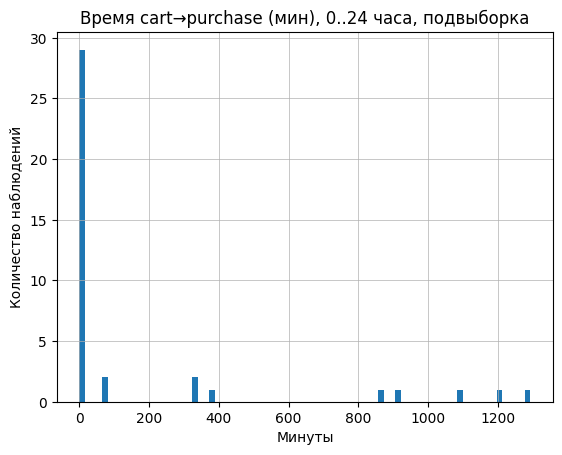

In [40]:
# Визуализация времени cart→purchase (минуты), ограничение 0..24 часа, подвыборка
sample_times = con.execute("""
WITH u AS (
  SELECT DISTINCT user_id
  FROM events
  WHERE random() < 0.01
),
ev AS (
  SELECT e.user_id, e.product_id, e.event_time, e.event_type
  FROM events e
  JOIN u USING(user_id)
),
carts AS (
  SELECT user_id, product_id, MIN(event_time) AS cart_time
  FROM ev
  WHERE event_type='cart'
  GROUP BY 1,2
),
purch AS (
  SELECT user_id, product_id, MIN(event_time) AS purchase_time
  FROM ev
  WHERE event_type='purchase'
  GROUP BY 1,2
),
c2p AS (
  SELECT datediff('minute', c.cart_time, p.purchase_time) AS min_cart_to_purchase
  FROM carts c
  JOIN purch p USING(user_id, product_id)
  WHERE p.purchase_time >= c.cart_time
)
SELECT min_cart_to_purchase
FROM c2p
WHERE min_cart_to_purchase BETWEEN 0 AND 24*60
  AND random() < 0.05
""").df()


plt.figure()
plt.hist(sample_times["min_cart_to_purchase"], bins=80)
plt.title("Время cart→purchase (мин), 0..24 часа, подвыборка")
plt.xlabel("Минуты")
plt.ylabel("Количество наблюдений")
plt.grid(True, linewidth=0.5)
plt.show()

## 3. Статистические проверки

In [43]:
# χ²-тест: различается ли вероятность покупки между децилями цены?
# Таблица наблюдений: куплено/не куплено по децилям цены среди просмотренных пар.
price_chi = con.execute("""
WITH base AS (
  SELECT
    ntile(10) OVER (ORDER BY price_max) AS price_decile,
    purchased
  FROM interactions
  WHERE viewed=1 AND price_max IS NOT NULL AND price_max > 0
)
SELECT
  price_decile,
  SUM(CASE WHEN purchased=1 THEN 1 ELSE 0 END) AS purchased_cnt,
  SUM(CASE WHEN purchased=0 THEN 1 ELSE 0 END) AS not_purchased_cnt
FROM base
GROUP BY 1
ORDER BY 1
""").df()

price_chi

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,price_decile,purchased_cnt,not_purchased_cnt
0,1,185977.0,12007570.0
1,2,239901.0,11953646.0
2,3,226329.0,11967217.0
3,4,222442.0,11971104.0
4,5,334938.0,11858608.0
5,6,372398.0,11821148.0
6,7,336034.0,11857512.0
7,8,268860.0,11924686.0
8,9,254262.0,11939284.0
9,10,299204.0,11894342.0


In [44]:
from scipy.stats import chi2_contingency

cont = price_chi[["purchased_cnt", "not_purchased_cnt"]].to_numpy()
chi2, p_value, dof, expected = chi2_contingency(cont)

print("chi2 =", chi2)
print("dof  =", dof)
print("p-value =", p_value)

chi2 = 119968.2612841552
dof  = 9
p-value = 0.0


In [45]:
# z-тест для долей: сравним долю покупателей в Q1 vs Q5 по активности (из activity_conv)
import math
from math import erf, sqrt

q1 = activity_conv.loc[activity_conv["activity_quintile"]==1].iloc[0]
q5 = activity_conv.loc[activity_conv["activity_quintile"]==5].iloc[0]

n1, x1 = int(q1["users"]), int(q1["buyers"])
n2, x2 = int(q5["users"]), int(q5["buyers"])

p1 = x1/n1
p2 = x2/n2
p_pool = (x1 + x2) / (n1 + n2)
se = math.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z = (p2 - p1) / se if se > 0 else float("nan")

def norm_cdf(zv):
    return 0.5 * (1 + erf(zv / sqrt(2)))

p_val = 2 * (1 - norm_cdf(abs(z)))

print("Q1 buyer_share =", p1)
print("Q5 buyer_share =", p2)
print("z =", z)
print("p-value =", p_val)

Q1 buyer_share = 0.0014155344178614707
Q5 buyer_share = 0.39169991029349505
z = 1017.031551062069
p-value = 0.0


# Выводы по EDA
## 1. Общая характеристика выборки

В исследовании используется журнал пользовательских событий электронной коммерции за период с ноября 2019 года по февраль 2020 года. Общий объём данных составляет 246 330 463 событий, совершённых 10 723 863 уникальными пользователями в отношении 306 293 товаров. Зафиксировано 56 293 798 пользовательских сессий.

Масштаб выборки позволяет рассматривать её как репрезентативную для анализа поведения пользователей крупного e-commerce сервиса. Объём данных обеспечивает статистическую устойчивость оценок и позволяет выявлять сложные поведенческие закономерности.

⸻

## 2. Структура событий и дисбаланс классов

Распределение типов событий характеризуется выраженной асимметрией:
1. просмотры (view) — 93,48%,
2. добавления в корзину (cart) — 4,85%,
3. покупки (purchase) — 1,67%.

Таким образом, данные обладают сильной несбалансированностью классов. Доля покупок менее 2% от общего числа событий указывает на необходимость применения специальных подходов при построении моделей машинного обучения (использование ROC-AUC, PR-AUC, балансировка классов, стратификация выборки).

⸻

## 3. Анализ воронки конверсии

Анализ воронки взаимодействия пользователей с товарами показал следующие значения:
1. конверсия view → cart ≈ 5,19%,
2. конверсия cart → purchase ≈ 34,43%,
3. итоговая конверсия view → purchase ≈ 1,79%.

Наиболее существенное сужение воронки происходит на этапе перехода от просмотра к добавлению в корзину. Следовательно, ключевой задачей прогнозирования является идентификация вероятности перехода пользователя от пассивного просмотра к активному намерению покупки.

Этап cart → purchase демонстрирует относительно высокую конверсию, что указывает на наличие выраженного покупательского намерения после добавления товара в корзину.

⸻

## 4. Структура пользовательской активности

Распределение числа событий на пользователя имеет выраженный «длинный хвост». Дополнительно выявлена высокая концентрация активности:
1. верхний 1% пользователей генерирует 22,2% всех событий;
2. верхние 5% пользователей — 49,9% событий;
3. верхние 10% пользователей — 65,96% событий.

Таким образом, 10% аудитории формируют две трети всей активности платформы. Это свидетельствует о высокой неоднородности пользовательской базы и необходимости сегментации пользователей по уровню вовлечённости.

⸻

## 5. Покупательское поведение и лояльность

Доля пользователей, совершивших хотя бы одну покупку, составляет около 12% от общего числа пользователей. При этом 51,3% покупателей совершают повторные покупки.

Это указывает на наличие устойчивого сегмента лояльных клиентов, формирующих значительную часть транзакционного оборота. Наличие повторных покупок подтверждает, что поведение пользователей не является исключительно случайным, а обладает выраженной стабильной компонентой.

⸻

## 6. Активность как предиктор вероятности покупки

Анализ зависимости вероятности покупки от уровня пользовательской активности выявил резкий рост конверсии по мере увеличения числа взаимодействий:
1. в нижнем квинтиле активности доля покупателей составляет 0,14%;
2. во втором квинтиле — 0,54%;
3. в третьем — 5,39%;
4. в четвёртом — 14,87%;
5. в верхнем квинтиле — 39,17%.

Вероятность покупки для наиболее активных пользователей почти в 300 раз превышает аналогичный показатель для наименее активных.

Данный результат демонстрирует высокую прогностическую ценность поведенческих признаков и подтверждает целесообразность использования характеристик вовлечённости пользователя при построении моделей прогнозирования предпочтений.

⸻

## 7. Ценовой анализ

Распределение цен товаров характеризуется правосторонней асимметрией:
1. медианная цена ≈ 164;
2. 75% товаров дешевле 348;
3. 99% товаров дешевле 1688.

Анализ конверсии по ценовым децилям показал немонотонную зависимость вероятности покупки от уровня цены. Максимальная конверсия view → purchase наблюдается в среднем ценовом диапазоне (децили 5–7), где вероятность покупки достигает ~3,05%, тогда как в нижнем ценовом сегменте она составляет около 1,5%.

Для этапа cart → purchase наблюдается рост конверсии от 32,8% в нижнем ценовом сегменте до более 50% в среднем диапазоне.

Полученные результаты свидетельствуют о различии поведенческих стратегий пользователей в зависимости от уровня цены и предполагают наличие ценовой чувствительности и различий в мотивации покупки.

⸻

## 8. Анализ переходов между событиями

Матрица переходов между событиями показывает, что наиболее частым является переход view → view, что отражает последовательный просмотр товаров. Значительное количество переходов cart → view указывает на возврат к просмотру после добавления товара в корзину.

Прямые переходы view → purchase встречаются значительно реже, что подтверждает важность промежуточных стадий воронки и последовательной модели поведения.

Данный результат обосновывает использование последовательных признаков (учёт предыдущих действий пользователя) при построении моделей прогнозирования следующего шага.

⸻

## 9. Ключевые выводы для последующего моделирования
1.	Поведение пользователей крайне неоднородно; активность сконцентрирована у ограниченной доли аудитории.
2.	Поведенческие признаки (частота, глубина взаимодействия) обладают высокой предсказательной способностью.
3.	Этап перехода от просмотра к корзине является основным узким местом воронки.
4.	Вероятность покупки зависит от ценового сегмента товара.
5.	Последовательность действий пользователя играет существенную роль.

Полученные результаты формируют основу для построения моделей машинного обучения, направленных на прогнозирование вероятности перехода пользователя к следующему этапу взаимодействия с товаром.